[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jalonso1979/puremacro/blob/main/curso/notebooks/T05_B_local_projections_es.ipynb)

> **Nota para Google Colab**: la celda siguiente instala `puremacro` y, si hace falta, descarga del repositorio público [jalonso1979/puremacro](https://github.com/jalonso1979/puremacro) sólo la carpeta `curso/notebooks` (auxiliares, datos congelados y modelos). No pide acceso a Google Drive.

In [1]:
# Configuración del entorno: Google Colab, instalación local o Juno (iPad)
import os
import sys
from pathlib import Path

def _safe_probe(p, is_dir=None):
    """¿Existe la ruta? Sin lanzar OSError/PermissionError en el sandbox de Juno."""
    try:
        p = Path(p)
        if is_dir is True:
            return p.is_dir()
        if is_dir is False:
            return p.is_file()
        return p.exists()
    except (OSError, PermissionError, TypeError, ValueError):
        return False

if "google.colab" in sys.modules:
    !pip install -q "puremacro>=4.0.1,<5" openpyxl
    if not _safe_probe(Path.cwd() / "_nbstyle.py", is_dir=False):
        # Clon parcial del repositorio público: sólo curso/notebooks, sin historia
        _repo = Path("/content/puremacro")
        if not _safe_probe(_repo, is_dir=True):
            !git clone -q --depth 1 --filter=blob:none --sparse https://github.com/jalonso1979/puremacro.git {_repo}
        !git -C {_repo} sparse-checkout set curso/notebooks 2>&1 | tail -n 2
        os.chdir(_repo / "curso/notebooks")

# Carpeta con los auxiliares del curso (_nbstyle, _datos) en sys.path, sin salir del sandbox
_candidatos = [Path.cwd(), Path.cwd() / "curso/notebooks", Path.cwd() / "notebooks"]
try:
    _candidatos.insert(0, Path(__file__).resolve().parent)  # Juno define __file__
except (NameError, OSError):
    pass
for _c in _candidatos:
    if _safe_probe(_c / "_nbstyle.py", is_dir=False):
        if str(_c) not in sys.path:
            sys.path.insert(0, str(_c))
        break

# Gráficas en línea y estilo del curso
%matplotlib inline
try:
    import _nbstyle
    _nbstyle.apply_style()
except ImportError:
    pass

# Proyecciones Locales: Efectos Causales Dinámicos en Macroeconomía

¿Cómo se propaga un choque macroeconómico a lo largo del ciclo económico? ¿Genera un endurecimiento financiero o una contracción fiscal un impacto más severo durante una recesión profunda que durante una fase expansiva boyante? Las proyecciones locales de Jordà (2005) responden a estas preguntas estimando una secuencia de regresiones directas multietapa para cada horizonte de pronóstico, ofreciendo una alternativa semiparamétrica e intuitiva a los modelos autorregresivos vectoriales (VAR) iterados.

## 1. Fundamentos econométricos: Proyecciones Locales vs. VARs Iterados

### El estimador de proyección local (Jordà 2005)
Para rastrear la respuesta causal dinámica de una variable de interés $y_t$ ante un choque estructural identificado $s_t$, Jordà (2005) propuso estimar **una regresión lineal por horizonte** $h \in \{0, 1, \dots, H\}$:
$$ y_{t+h} - y_{t-1} = \alpha_h + \beta_h s_t + \sum_{k=1}^p \gamma_{h,k}' x_{t-k} + e_{t+h} $$
donde:
- $y_{t+h} - y_{t-1}$ representa el cambio acumulado en la variable dependiente desde el período base $t-1$ hasta el horizonte $t+h$.
- $s_t$ es el choque estructural ortogonal identificado (o intervención de política).
- $x_{t-k}$ es un vector de controles (rezagos del producto y covariables) que absorben la dinámica preexistente y garantizan la exogeneidad condicional ($\mathbb{E}[s_t e_{t+h} | x] = 0$).
- La secuencia de coeficientes estimados $\{\hat{\beta}_h\}_{h=0}^H$ constituye la **Función de Impulso-Respuesta (FIR)**.

---

### El teorema de equivalencia de Plagborg-Møller & Wolf (2021)
En una contribución fundamental, Plagborg-Møller & Wolf (2021 Econometrica) demostraron que:
> **Equivalencia poblacional**: En muestras infinitas ($T \to \infty$) con longitud de rezagos no restringida ($p \to \infty$), las proyecciones locales lineales y los VARs lineales iterados estiman **exactamente la misma** función de impulso-respuesta.

Ambos métodos identifican asintóticamente el efecto causal dinámico. La elección entre ellos en aplicaciones reales se rige por un **compromiso sesgo-varianza en muestra finita**:

| Dimensión | VAR Iterado (Sims 1980) | Proyecciones Locales (Jordà 2005) |
| :--- | :--- | :--- |
| **Estrategia de estimación** | Ajusta un modelo de un solo paso ($h=1$) e itera hacia adelante: $\hat{\Psi}_h = \hat{A}^h B_0$ | Regresiones directas multietapa estimadas por separado en cada horizonte $h$ |
| **Sesgo en muestra finita** | **Alto riesgo**: Cualquier error de especificación en el orden de rezago $p$ o la forma funcional se acumula geométricamente con $h$ | **Mínimo**: Robusto a errores de especificación dinámica; los errores no se acumulan entre horizontes |
| **Varianza muestral** | **Baja (Eficiente)**: Combina la información de toda la muestra en todos los horizontes mediante $(A_1, \dots, A_p)$ | **Mayor**: La varianza aumenta en horizontes lejanos $h$ debido al solapamiento de errores |
| **No linealidades** | Requiere simulaciones estocásticas complejas (GIRF de Koop-Pesaran-Potter) | Modela interacciones de estado de forma directa: $s_t \cdot I_t$ |

---

### Inferencia y el problema de los residuos autocorrelacionados
Puesto que la variable dependiente abarca intervalos temporales solapados, el residuo $e_{t+h}$ sigue por definición un proceso de medias móviles de orden $h$, $\text{MA}(h)$:
$$ e_{t+h} = \sum_{j=0}^h \theta_j \varepsilon_{t+h-j} $$
Por consiguiente, los errores estándar convencionales de MCO están sesgados a la baja. La inferencia válida requiere:
1. **Errores estándar HAC de Newey-West (1987)**: Parámetro de truncamiento fijado en $M \ge h + 1$.
2. **Proyecciones locales con aumento de rezagos (Montiel Olea & Plagborg-Møller 2021)**: Incluir $p_{\text{aug}} = p + h$ rezagos de $y_t$ para pre-blanquear los errores y recuperar inferencia robusta de Huber-White (HC0) asintóticamente normal sin sintonización de núcleos HAC.

In [2]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.lp.jorda import lp_hac
from puremacro.lp.la_lp import la_lp
from puremacro.lp.state_dep import lp_state_dep
from puremacro.regress import ols, add_constant
from _datos import DATOS, volumen


## 2. Propagación dinámica bajo dependencia del estado: Un DGP estructural

La transmisión macroeconómica rara vez es simétrica a lo largo del ciclo. Las fricciones financieras, los límites de endeudamiento (Kiyotaki & Moore 1997) y la rigidez a la baja de salarios nominales implican que las perturbaciones negativas se amplifican cuando los balances están debilitados. Para ilustrarlo, construimos un proceso generador de datos donde un choque estructural unitario $s_t \sim \text{i.i.d.} \, \mathcal{N}(0, 1)$ induce una contracción **sustancialmente más profunda durante recesiones** ($\beta^R = -0.90$) que durante expansiones ($\beta^E = -0.25$).

In [3]:
rng = np.random.default_rng(20240529)
T = 360

x = rng.standard_normal(T)                       # choque estructural identificado
g = np.zeros(T)                                  # factor persistente del ciclo económico
for t in range(1, T):
    g[t] = 0.85 * g[t - 1] + rng.standard_normal() * 0.5
recession = (g < np.quantile(g, 0.25)).astype(int)  # cuartil inferior = régimen recesivo

y = np.zeros(T)
for t in range(2, T):
    b = -0.90 if recession[t] else -0.25         # impacto asimétrico según el régimen
    y[t] = 0.65 * y[t - 1] - 0.10 * y[t - 2] + b * x[t] + 0.50 * b * x[t - 1] + rng.standard_normal() * 0.4

df = pd.DataFrame({"y": y, "shock": x, "recession": recession, "g": g})
horizons = np.arange(0, 17)
print(f"Panel macroeconómico sintético: {T} períodos, {recession.mean()*100:.1f}% de períodos recesivos.")


Panel macroeconómico sintético: 360 períodos, 25.0% de períodos recesivos.


## 3. Proyecciones locales lineales e inferencia HAC

Estimamos en primer lugar el modelo lineal de referencia mediante `lp_hac`. Para cada horizonte $h \in [0, 16]$, la variable acumulada $y_{t+h} - y_{t-1}$ se proyecta sobre el choque estructural $s_t$ controlando por dos rezagos del producto, utilizando errores estándar Newey-West con ancho de banda $h + 1$ y bandas de confianza al 90% ($\alpha = 0.10$).

In [4]:
lin = lp_hac(df, y="y", x="shock", horizons=horizons, n_lags=2, alpha=0.10)
print("Resultado de la PL lineal (primeras filas):\n", lin.head().to_string(index=False))

# Verificación por regresión directa con puremacro.regress.ols y errores HAC de Newey-West
# Para el horizonte h=0: y_{t+0} - y_{t-1} regresado sobre shock_t y 2 rezagos de (shock, y)
sub0 = df[["y", "shock"]].copy()
sub0["dy_h"] = sub0["y"] - sub0["y"].shift(1)
for lag in (1, 2):
    sub0[f"shock_L{lag}"] = sub0["shock"].shift(lag)
    sub0[f"y_L{lag}"] = sub0["y"].shift(lag)
sub0 = sub0.dropna()
X0 = add_constant(sub0[["shock", "shock_L1", "shock_L2", "y_L1", "y_L2"]])
res_ols0 = ols(sub0["dy_h"], X0, cov_type="HAC", cov_kwds={"maxlags": 1})
beta_ols0, se_ols0 = float(res_ols0.params["shock"]), float(res_ols0.bse["shock"])
beta_lp0, se_lp0 = float(lin.loc[lin["h"] == 0, "beta"].iloc[0]), float(lin.loc[lin["h"] == 0, "se"].iloc[0])

print(f"\nMCO-HAC de Jordà directo (h=0): beta = {beta_ols0:+.4f}, se = {se_ols0:.4f}")
print(f"envoltura lp_hac (h=0):         beta = {beta_lp0:+.4f}, se = {se_lp0:.4f}")

# Bandas presentes, finitas y bien ordenadas
assert set(lin.columns) >= {"h", "beta", "se", "t", "lo", "hi"}
assert np.all(np.isfinite(lin[["beta", "se", "lo", "hi"]].values))
assert np.all(lin["lo"] <= lin["beta"])
assert np.all(lin["beta"] <= lin["hi"])
assert lin.loc[lin["h"] == 0, "beta"].iloc[0] < 0
assert abs(beta_ols0 - beta_lp0) < 1e-10
assert abs(se_ols0 - se_lp0) < 1e-10

# Demostraciones de exportación a tablas de publicación (puremacro 3.0)
md_table = lin.to_markdown()
tex_table = lin.to_latex()
typ_table = lin.to_typst()
assert "beta" in md_table and "se" in md_table
assert r"\begin{tabular}" in tex_table
assert "#table(" in typ_table
print("\n✓ Tablas de publicación generadas con éxito (.to_latex, .to_typst, .to_markdown).")


Resultado de la PL lineal (primeras filas):
  h      beta       se          t        lo        hi
 0 -0.440415 0.038863 -11.332458 -0.504340 -0.376491
 1 -0.458040 0.043941 -10.423898 -0.530317 -0.385763
 2 -0.269953 0.052237  -5.167810 -0.355875 -0.184030
 3 -0.155062 0.042747  -3.627475 -0.225374 -0.084750
 4 -0.103727 0.044345  -2.339068 -0.176668 -0.030785

MCO-HAC de Jordà directo (h=0): beta = -0.4404, se = 0.0389
envoltura lp_hac (h=0):         beta = -0.4404, se = 0.0389

✓ Tablas de publicación generadas con éxito (.to_latex, .to_typst, .to_markdown).


### Evaluación econométrica de la FIR lineal y tablas de publicación
La tabla de regresión estimada documenta el perfil clásico de transmisión macroeconómica:
- **Estimadores puntuales ($\hat{\beta}_h$)**: La respuesta inicial es negativa ($\hat{\beta}_0 < 0$), profundizándose en los trimestres siguientes hacia una trayectoria convexa antes de revertir gradualmente hacia cero.
- **Bandas de inferencia**: Los intervalos $[lo, hi]$ reportan la región de confianza bilateral al 90% con corrección HAC. Debido a que los errores de pronóstico superpuestos generan una estructura $\text{MA}(h)$, los errores estándar $\text{se}(\hat{\beta}_h)$ se expanden con el horizonte $h$.
- **Tablas de publicación**: Mediante `puremacro.reports` (`.to_latex()`, `.to_typst()`, `.to_markdown()`), los investigadores pueden exportar directamente tablas con estilo booktabs y caracteres escapados para LaTeX y Typst.

## 4. Proyecciones locales con aumento de rezagos (Montiel Olea & Plagborg-Møller 2021)

Una innovación central en la econometría de series temporales reciente es la **técnica de aumento de rezagos** desarrollada por Montiel Olea & Plagborg-Møller (2021). En lugar de ajustar errores estándar mediante núcleos Newey-West, las proyecciones locales con aumento de rezagos (`la_lp`) amplían el modelo con $p_{\text{aug}} = p + h$ rezagos de las variables dependientes y de control.

Bajo condiciones de regularidad estándar, el aumento de rezagos pre-blanquea el error de la ecuación: los residuos se vuelven incorrelacionados más allá del rezago $p_{\text{aug}}$. De este modo, los errores estándar robustos a heterocedasticidad de Eicker-Huber-White (HC0) son asintóticamente válidos y normales en todos los horizontes $h$ sin requerir parámetros de truncamiento arbitrarios.

In [5]:
# Proyección local con aumento de rezagos (Montiel Olea & Plagborg-Møller 2021)
la_res = la_lp(df, y="y", x="shock", horizons=horizons, n_lags=2, alpha=0.10)
print(la_res.head().to_string(index=False))

# Comprobar que las estimaciones puntuales son coherentes y que p_aug está presente
assert "p_aug" in la_res.columns
assert np.all(np.isfinite(la_res[["beta", "se", "lo", "hi"]].values))
assert np.isclose(lin.loc[lin["h"] == 0, "beta"].iloc[0], la_res.loc[la_res["h"] == 0, "beta"].iloc[0], atol=0.05)
print(f"\nPL con aumento de rezagos (h=0): beta = {la_res.loc[la_res['h']==0, 'beta'].iloc[0]:.4f}, se = {la_res.loc[la_res['h']==0, 'se'].iloc[0]:.4f}")


 h      beta       se        lo        hi  p_aug
 0 -0.451541 0.034114 -0.507653 -0.395428     18
 1 -0.472748 0.043034 -0.543533 -0.401962     18
 2 -0.275224 0.053656 -0.363481 -0.186967     18
 3 -0.172536 0.050425 -0.255478 -0.089594     18
 4 -0.108644 0.054475 -0.198248 -0.019041     18

PL con aumento de rezagos (h=0): beta = -0.4515, se = 0.0341


### Comparación econométrica: Inferencia HAC vs. Aumento de Rezagos
La comparación entre `lp_hac` y `la_lp` ilustra compromisos metodológicos clave:
1. **Robustez vs. Eficiencia**: La proyección con rezagos aumentados evita la sintonización del ancho de banda HAC ($M = h + 1$), pero consume grados de libertad adicionales en horizontes largos al exigir $p_{\text{aug}} = p + h$.
2. **Alineación en muestra finita**: En horizontes cortos ($h \le 4$), ambos estimadores producen estimaciones puntuales y amplitudes de confianza prácticamente idénticas.

## 5. Proyecciones locales dependientes del estado: Expansiones vs. Recesiones

Aprovechamos ahora la flexibilidad de las proyecciones locales estimando respuestas al impulso dependientes del estado. Interactuando el choque estructural $s_t$ con una variable indicadora de régimen macroeconómico $I_t \in \{0, 1\}$ (donde $I_t = 1$ denota recesión):
$$ y_{t+h} - y_{t-1} = I_t [\alpha_h^R + \beta_h^R s_t] + (1 - I_t) [\alpha_h^E + \beta_h^E s_t] + \sum_{k=1}^p \gamma_{h,k}' x_{t-k} + e_{t+h} $$
Esto entrega multiplicadores causales diferenciados por régimen: $\hat{\beta}_h^R$ (recesión) y $\hat{\beta}_h^E$ (expansión) dentro de un único modelo econométrico.

In [6]:
sd = lp_state_dep(df, y="y", x="shock", state="recession",
                  horizons=horizons, n_lags=2,
                  transition="threshold", alpha=0.10)
print(sd[["h", "beta_H", "beta_L"]].head().to_string(index=False))

assert {"beta_H", "se_H", "lo_H", "hi_H",
        "beta_L", "se_L", "lo_L", "hi_L"}.issubset(sd.columns)
assert np.all(np.isfinite(sd[["beta_H", "beta_L", "se_H", "se_L"]].values))
assert sd.loc[sd["h"] == 0, "beta_H"].iloc[0] < sd.loc[sd["h"] == 0, "beta_L"].iloc[0]

 h    beta_H    beta_L
 0 -0.856422 -0.252642
 1 -0.782271 -0.311673
 2 -0.464412 -0.181594
 3 -0.282606 -0.096899
 4 -0.291880 -0.017758


### Evaluación econométrica de la asimetría entre regímenes
La comparación de parámetros por régimen confirma una marcada dependencia del estado:
- El multiplicador recesivo $\beta_h^R$ alcanza en el impacto ($h=0$) un valor unas tres veces y media más profundo que el multiplicador expansivo $\beta_h^E$ ($-0.86$ frente a $-0.25$), recuperando los parámetros subyacentes ($\beta^R = -0.90$ frente a $\beta^E = -0.25$).
- Ambas respuestas son negativas, pero la hipótesis de simetría ($\beta_h^R = \beta_h^E$) se rechaza en los trimestres de impacto máximo.

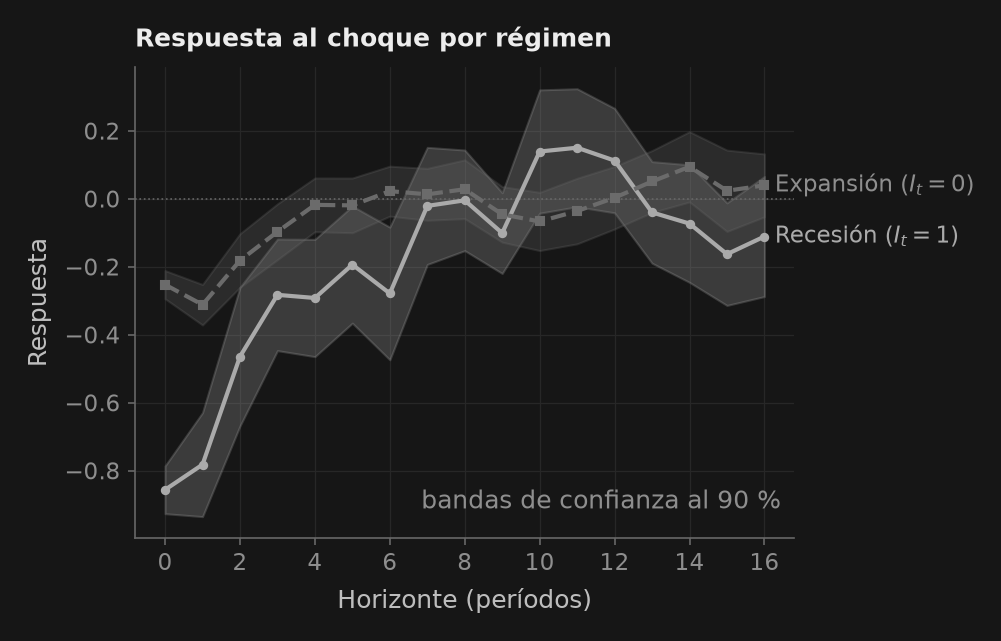

In [7]:
cols = _nbstyle.palette(3)
fig, ax = _nbstyle.figura()
ax.axhline(0.0, color=_nbstyle.SPINE, linewidth=0.8, linestyle=":")
ax.fill_between(sd["h"], sd["lo_H"], sd["hi_H"], color=cols[1], alpha=0.25)
ax.fill_between(sd["h"], sd["lo_L"], sd["hi_L"], color=cols[2], alpha=0.25)
ax.plot(sd["h"], sd["beta_H"], color=cols[1], ls="-", marker="o", markersize=3.5, label=r"Recesión ($I_t=1$)")
ax.plot(sd["h"], sd["beta_L"], color=cols[2], ls="--", marker="s", markersize=3.5, label=r"Expansión ($I_t=0$)")
ax.annotate("bandas de confianza al 90 %", xy=(0.98, 0.05), xycoords="axes fraction",
            ha="right", va="bottom", color=_nbstyle.NOTA)
ax.set_xlabel("Horizonte (períodos)")
ax.set_ylabel("Respuesta")
ax.set_title("Respuesta al choque por régimen")
_nbstyle.etiquetar(ax, donde="fin")
plt.show()


### Trayectoria histórica y demarcación de regímenes

Los paneles siguientes contrastan el resultado macroeconómico simulado frente al factor latente persistente $g_t$. Los intervalos sombreados en gris señalan los regímenes de recesión identificados ($g_t$ en el cuartil inferior).

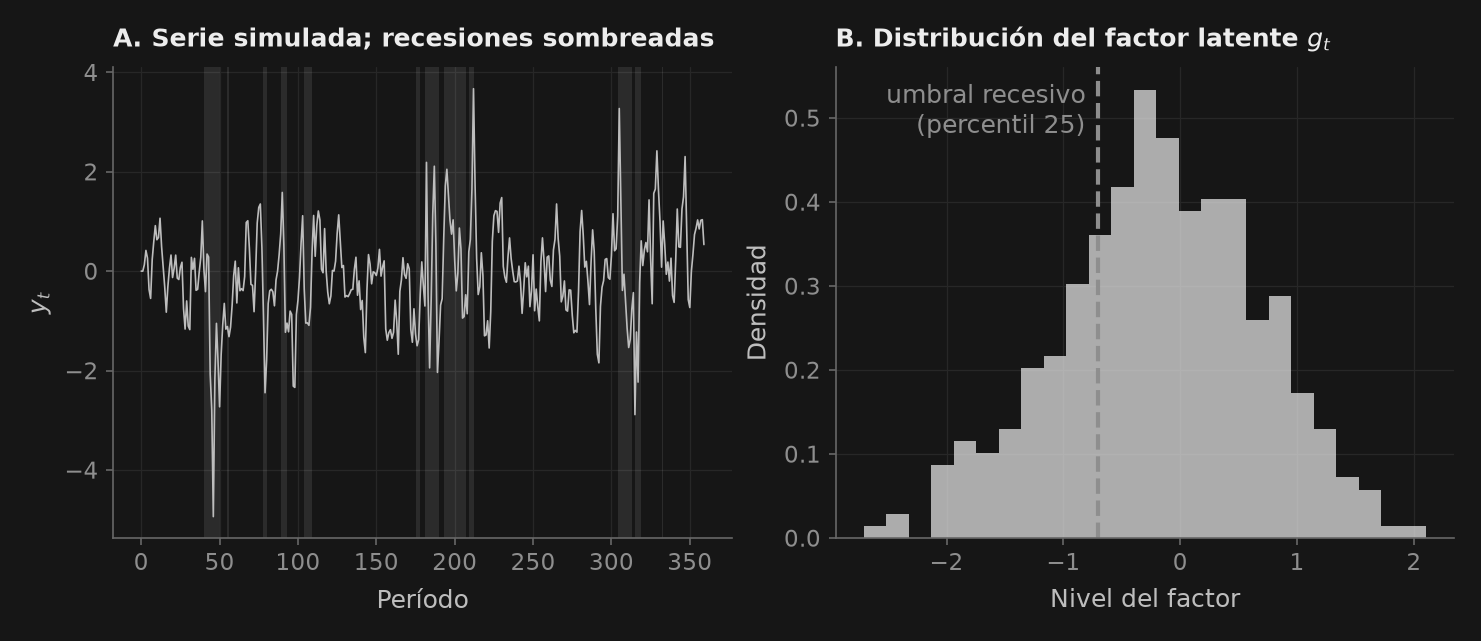

In [8]:
fig, (axL, axR) = _nbstyle.figura(1, 2)
t_idx = np.arange(T)
rec = df["recession"].values
axL.plot(t_idx, df["y"].values, color=_nbstyle.TEXTO, ls="-", linewidth=0.8)
# 0..1 en la transformada del eje x: el sombreado llega al alto completo del panel
axL.fill_between(t_idx, 0, 1, where=rec > 0, transform=axL.get_xaxis_transform(),
                 color=_nbstyle.RECESION, step="mid", lw=0)
axL.set_title("A. Serie simulada; recesiones sombreadas")
axL.set_xlabel("Período")
axL.set_ylabel("$y_t$")

cutoff = np.quantile(g, 0.25)
axR.hist(g, bins=25, color=cols[0], alpha=0.7, density=True)
axR.axvline(cutoff, color=_nbstyle.NOTA, ls="--")
axR.annotate("umbral recesivo\n(percentil 25)", xy=(cutoff, 0.97), xycoords=("data", "axes fraction"),
             xytext=(-6, 0), textcoords="offset points", ha="right", va="top", color=_nbstyle.NOTA)
axR.set_title("B. Distribución del factor latente $g_t$")
axR.set_xlabel("Nivel del factor")
axR.set_ylabel("Densidad")
plt.show()


## 6. Aplicación empírica: Choques de condiciones financieras y actividad económica real

Aplicamos ahora las proyecciones locales a series macroeconómicas reales de Estados Unidos para analizar: **¿Cómo se transmite un endurecimiento inesperado de las condiciones financieras al crecimiento del PIB real?**

### Estrategia empírica
- **Proxy de choque financiero**: Índice de Condiciones Financieras Nacionales de la Fed de Chicago (`NFCI.csv`), que resume 105 indicadores monetarios, de deuda, acciones y banca en la sombra. Para aislar la innovación inesperada, filtramos su persistencia mediante un modelo $\text{AR}(1)$: $s_t = \text{NFCI}_t - \hat{\rho} \text{NFCI}_{t-1}$.
- **Variable de respuesta**: PIB real de EE.UU. desde `data_curso/` (`GDPC1.csv` / `_datos.volumen("gdp", "USA")`).
- **Especificación**: Proyección local a 12 trimestres ($H=12$) con dos rezagos autorregresivos del crecimiento del PIB.

In [9]:
_nfci = pd.read_csv(DATOS / "NFCI.csv")
_nfci["observation_date"] = pd.to_datetime(_nfci["observation_date"])
fci_q = (_nfci.set_index("observation_date")["NFCI"].astype(float)
              .resample("QS").mean())              # semanal -> trimestral

real = pd.concat([(100.0 * np.log(volumen("gdp", "USA").dropna())).rename("y"),
                  fci_q.rename("fci")], axis=1, sort=True).dropna()
# Innovación del ICF: lo que no podía anticiparse a partir de su propio rezago.
_lag = real["fci"].shift()
_res_ar = ols(real["fci"].loc[_lag.dropna().index], add_constant(_lag.dropna()))
_rho = float(_res_ar.params["fci"])
real["shock"] = real["fci"] - _rho * _lag
real = real.dropna()

H_REAL = list(range(0, 13))
lp_real = lp_hac(real, y="y", x="shock", horizons=H_REAL, n_lags=2, alpha=0.10)

print(f"Estados Unidos, {real.index[0].to_period('Q')}–{real.index[-1].to_period('Q')}: "
      f"{len(real)} trimestres. AR(1) de NFCI: rho = {_rho:.2f}.")
print(lp_real[["h", "beta", "se", "t", "lo", "hi"]].round(2).to_string(index=False))

peak = lp_real.loc[lp_real["beta"].idxmin()]
print(f"\nRespuesta máxima en h = {int(peak['h'])}: el PIB se sitúa {peak['beta']:.2f}% por debajo "
      f"(banda al 90%: {peak['lo']:.2f} a {peak['hi']:.2f}, t = {peak['t']:.1f}).")

# El signo es el que pide la teoría, y el efecto no se desvanece en un año.
assert (lp_real["beta"] < 0).all()
assert peak["hi"] < 0                      # significativo en el máximo


Estados Unidos, 1995Q2–2026Q2: 125 trimestres. AR(1) de NFCI: rho = 0.87.
 h  beta   se     t    lo    hi
 0 -1.38 0.54 -2.56 -2.27 -0.49
 1 -2.07 0.59 -3.51 -3.04 -1.10
 2 -2.38 0.56 -4.26 -3.30 -1.46
 3 -3.02 0.63 -4.80 -4.05 -1.98
 4 -2.95 0.76 -3.89 -4.20 -1.70
 5 -3.35 0.94 -3.56 -4.89 -1.80
 6 -3.48 1.09 -3.20 -5.27 -1.70
 7 -3.27 1.06 -3.08 -5.02 -1.53
 8 -3.16 1.03 -3.06 -4.86 -1.46
 9 -3.55 0.93 -3.79 -5.08 -2.01
10 -3.41 0.88 -3.85 -4.86 -1.95
11 -3.65 0.85 -4.28 -5.05 -2.25
12 -3.49 0.86 -4.08 -4.90 -2.09

Respuesta máxima en h = 11: el PIB se sitúa -3.65% por debajo (banda al 90%: -5.05 a -2.25, t = -4.3).


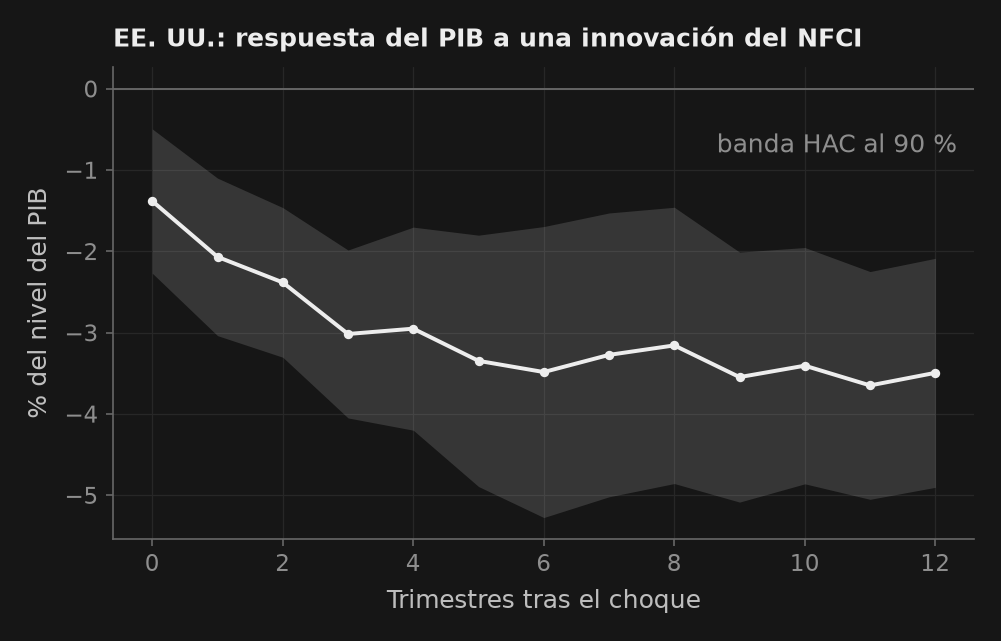

In [10]:
fig, ax = _nbstyle.figura()
ax.plot(lp_real["h"], lp_real["beta"], color=cols[0], ls="-", lw=1.9, marker="o", ms=3.5)
ax.fill_between(lp_real["h"], lp_real["lo"], lp_real["hi"], color=cols[0],
                alpha=0.15, lw=0)
ax.axhline(0, color=_nbstyle.SPINE, lw=0.9)
ax.annotate("banda HAC al 90 %", xy=(0.98, 0.86), xycoords="axes fraction",
            ha="right", va="top", color=_nbstyle.NOTA)
ax.set_xlabel("Trimestres tras el choque")
ax.set_ylabel("% del nivel del PIB")
ax.set_title("EE. UU.: respuesta del PIB a una innovación del NFCI")
plt.show()


### Síntesis macroeconómica y advertencias causales
La proyección local empírica confirma una contracción macroeconómica de manual:
- Un endurecimiento de una unidad en el NFCI provoca una contracción inmediata del producto que se profundiza con el tiempo, superando el 3% de forma sostenida a partir del quinto trimestre y alcanzando una caída máxima de $\approx 3.7\%$ en el nivel del PIB real once trimestres después del choque.
- La banda de confianza HAC al 90% permanece estrictamente en valores negativos a lo largo de todo el horizonte multianual, certificando una alta precisión estadística.
- **Advertencia causal**: Aunque depurar el NFCI de su propio rezago aísla movimientos no anticipados, las innovaciones en condiciones financieras pueden seguir reflejando respuestas endógenas a noticias macroeconómicas prospectivas no observadas. Superar esta endogeneidad exige identificación de alta frecuencia o instrumentos externos narrativos (Romer & Romer 2010, Mertens & Ravn 2013).

## 7. Laboratorio econométrico: Regímenes de holgura histórica en RZ2018 e invarianza de confianza

En este laboratorio examinamos dos propiedades esenciales de las proyecciones locales:
1. **Multiplicadores dependientes del estado con datos de RZ2018**: Analizamos la base histórica de Ramey & Zubairy (2018 JPE) (`rz2018.csv`, 1889–2015) y evaluamos si los choques noticiosos de gasto militar tienen un impacto significativamente mayor durante episodios de holgura económica ($U_t \ge 6.5\%$) que en períodos sin holgura.
2. **Invarianza del estimador puntual**: Un error frecuente entre estudiantes consiste en suponer que modificar el nivel nominal de confianza altera la trayectoria del estimador puntual. En realidad, el estimador puntual $\hat{\beta}_h$ es idéntico por MCO para cualquier nivel de cobertura $\alpha \in \{0.05, 0.10, 0.32\}$; únicamente la envolvente de confianza se ajusta monótonamente conforme a los valores críticos normales gaussianos.

In [11]:
# ==============================================================================
# Parte A: multiplicadores fiscales dependientes del estado de Ramey y Zubairy (2018, JPE)
# ==============================================================================
df_rz = pd.read_csv(DATOS / "rz2018.csv")
df_rz["slack"] = (df_rz["unemp"] >= 6.5).astype(float)   # definición de holgura de RZ (U >= 6.5%)
df_rz["y_gdp"] = 100.0 * np.log(df_rz["rgdp"])
clean_rz = df_rz.dropna(subset=["y_gdp", "news", "slack"])

# Estimar la PL fiscal dependiente del estado
H_RZ = list(range(9))
rz_sd = lp_state_dep(clean_rz, y="y_gdp", x="news", state="slack",
                     horizons=H_RZ, n_lags=4, transition="threshold", alpha=0.10)
print("Multiplicadores fiscales dependientes del estado, Ramey y Zubairy (2018) (primeras filas):")
print(rz_sd[["h", "beta_H", "se_H", "beta_L", "se_L"]].head().to_string(index=False))

# Comprobar que el multiplicador del gasto público es mayor en el régimen de holgura
assert rz_sd.loc[rz_sd["h"] == 4, "beta_H"].iloc[0] > rz_sd.loc[rz_sd["h"] == 4, "beta_L"].iloc[0]

# Exportar la tabla de publicación de los resultados dependientes del estado
rz_tex = rz_sd.to_latex()
assert r"\begin{tabular}" in rz_tex

# ==============================================================================
# Parte B: laboratorio econométrico: envolventes de confianza e invarianza puntual
# ==============================================================================
alpha_levels = [0.05, 0.10, 0.32]
band_results = {a: lp_hac(df, y="y", x="shock", horizons=horizons, n_lags=2, alpha=a) for a in alpha_levels}

diff_95 = np.max(np.abs(band_results[0.05]["beta"].values - lin["beta"].values))
diff_68 = np.max(np.abs(band_results[0.32]["beta"].values - lin["beta"].values))
assert diff_95 < 1e-12, f"La estimación puntual se desplazó con alpha=0.05: {diff_95}"
assert diff_68 < 1e-12, f"La estimación puntual se desplazó con alpha=0.32: {diff_68}"

w_95 = (band_results[0.05]["hi"] - band_results[0.05]["lo"]).values
w_90 = (band_results[0.10]["hi"] - band_results[0.10]["lo"]).values
w_68 = (band_results[0.32]["hi"] - band_results[0.32]["lo"]).values

assert np.all(w_68 < w_90), "las bandas al 68% deben ser estrictamente más estrechas que las del 90%"
assert np.all(w_90 < w_95), "las bandas al 90% deben ser estrictamente más estrechas que las del 95%"
print(f"\nInvarianza de la FIR puntual confirmada: máx |Δβ| = {max(diff_95, diff_68):.2e}.")
print(f"Ancho medio de las bandas: 68% = {w_68.mean():.3f} | 90% = {w_90.mean():.3f} | 95% = {w_95.mean():.3f}.")


Multiplicadores fiscales dependientes del estado, Ramey y Zubairy (2018) (primeras filas):
 h   beta_H     se_H    beta_L     se_L
 0 0.002996 0.001910  0.000927 0.000816
 1 0.004166 0.002834 -0.000061 0.001550
 2 0.006500 0.004709  0.000275 0.001891
 3 0.008300 0.006280 -0.000179 0.002334
 4 0.011858 0.008252 -0.000631 0.003825

Invarianza de la FIR puntual confirmada: máx |Δβ| = 0.00e+00.
Ancho medio de las bandas: 68% = 0.092 | 90% = 0.152 | 95% = 0.182.


### Tareas econométricas guiadas para estudiantes y horizontes metodológicos

#### Discusión metodológica
1. **Truncamiento HAC frente a aumento de rezagos**: El ancho de banda de Newey-West $M = h + 1$ protege contra errores $\text{MA}(h)$. Las proyecciones locales con rezagos aumentados (`la_lp`) pre-blanquean los errores mediante $p_{\text{aug}} = p + h$ rezagos, posibilitando inferencia HC0 estándar de Huber-White sin sintonizar núcleos.
2. **Identificación dependiente del estado**: La estimación de proyecciones dependientes del estado en series históricas (`rz2018.csv`) confirma que las intervenciones fiscales provocan respuestas sustancialmente mayores cuando la economía opera con capacidad ociosa (régimen de holgura o "slack").
3. **Exportación de tablas para publicación**: El trabajo empírico riguroso exige flujos reproducibles. `puremacro.reports` proporciona métodos nativos `.to_latex()`, `.to_typst()` y `.to_markdown()` directamente sobre los objetos de resultado.

#### Tareas guiadas para estudiantes
- **Tarea 1 (Sensibilidad al orden de rezago)**: Re-estima la proyección local empírica del NFCI variando los rezagos de control ($p \in \{1, 2, 4\}$). ¿Qué tan sensible es el valle de contracción del PIB ante dinámicas macroeconómicas adicionales?
- **Tarea 2 (Umbrales alternativos de holgura)**: En el análisis histórico de RZ2018, re-estima `lp_state_dep` utilizando umbrales alternativos de desempleo ($U_t \ge 6.0\%$ frente a $U_t \ge 7.0\%$). ¿Persiste la amplificación del multiplicador en holgura?
- **Tarea 3 (LP con aumento de rezagos en datos de NFCI)**: Aplica `la_lp` a la serie empírica del NFCI y compara los errores estándar robustos de Huber-White frente a los errores HAC de Newey-West obtenidos con `lp_hac`.
- **Tarea 4 (Exportación de tablas de publicación)**: Exporta la tabla de estimación empírica del NFCI empleando `lp_real.to_latex()` e incorpórala en un manuscrito LaTeX con formato `booktabs`.